In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import helpers
from modules import metrics
from modules import read_timeseries as read
from modules import ADCP_quality_flagging as custom
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [3]:
# Configuration
start_date = '2023-01-14'
end_date = '2023-01-15'

# model output
dir_model_output = Path(r'C:/Users/karoa/MOHID_internship/MOHID_single_domain/res')
folders = ['Run1']
name = 'layer' 




## Calibration against gauge data

### Reading files

In [4]:
# reading files

# model output
all_results = {folder: read.read_files(folder, name, dir_model_output) for folder in folders}



In [5]:
gauge = pd.read_csv(r'C:/Users/karoa/MOHID_internship/MOHID_model_workflow/data/preprocessing/WATER_LEVEL_2023_1_13_2023_2_23.csv')
gauge['date'] = pd.to_datetime(gauge['date'])
gauge.set_index('date', inplace=True)
gauge = gauge.loc[start_date:end_date]



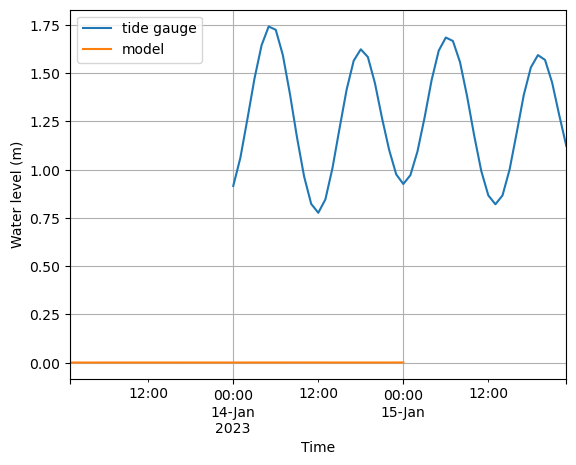

In [6]:
gauge['water_level'].plot(label='tide gauge')
all_results['Run1'][50]['water_level'].plot(label='model')
plt.legend()
plt.ylabel('Water level (m)')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [7]:
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]
df_gauge = metrics.compare_runs(
    runs={
        "model_output": all_results['Run1'][37]
    },
    reference=gauge,
    metric_fns=metric_fns,
    columns=['water_level'],
)
df_gauge

,run,variable,rmse,bias,mss,pearson_r
0,model_output,water_level,1.29539,-1.259488,0.286741,-0.174627
